<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/ML_week6_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [237]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

학습 데이터

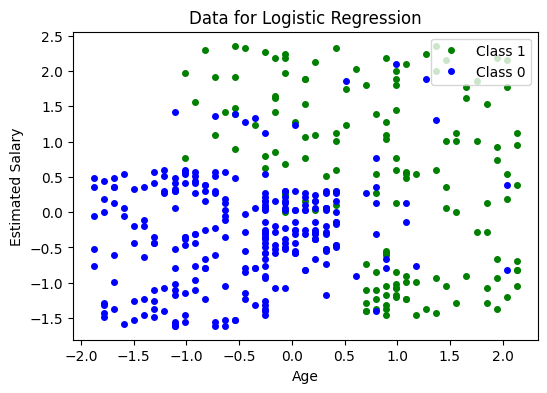

In [239]:
data = pd.read_csv('/content/Social_Network_Ads.csv')

# 정규화 (표준화)
scaler = StandardScaler()
data[['Age', 'EstimatedSalary']] = scaler.fit_transform(data[['Age', 'EstimatedSalary']])

X = np.hstack((np.ones((400, 1)), data[['Age', 'EstimatedSalary']].values))

# 행렬로 변환
X = np.asmatrix(X)

# y 생성
y = data['Purchased'].values
C1 = np.where(y == True)[0]
C0 = np.where(y == False)[0]

y = np.empty([400, 1])
y[C1] = 1
y[C0] = 0

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(X[C1, 1], X[C1, 2], 'go', markersize=4, label='Class 1')
plt.plot(X[C0, 1], X[C0, 2], 'bo', markersize=4, label='Class 0')
plt.title('Data for Logistic Regression')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(loc=1)
plt.show()

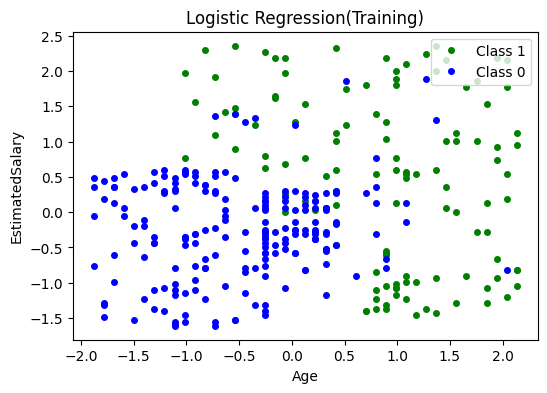

In [240]:
C1_train = np.where(y_train == 1)[0]   #
C0_train = np.where(y_train == 0)[0]


plt.figure(figsize=(6, 4))
plt.plot(X_train[C1_train, 1], X_train[C1_train, 2], 'go', markersize=4, label='Class 1')
plt.plot(X_train[C0_train, 1], X_train[C0_train, 2], 'bo', markersize=4, label='Class 0')
plt.title('Logistic Regression(Training)')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.legend(loc=1)

plt.show()


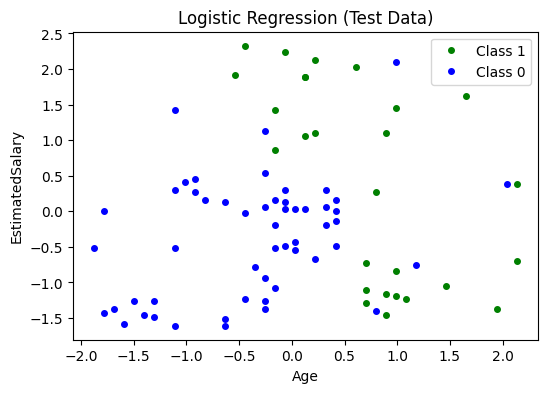

In [241]:
C1_test = np.where(y_test == 1)[0]
C0_test = np.where(y_test == 0)[0]


plt.figure(figsize=(6, 4))
plt.plot(X_test[C1_test, 1], X_test[C1_test, 2], 'go', markersize=4, label='Class 1')
plt.plot(X_test[C0_test, 1], X_test[C0_test, 2], 'bo', markersize=4, label='Class 0')
plt.title('Logistic Regression (Test Data)')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.legend(loc=1)

plt.show()

경사하강법 이용

In [242]:
def h(X, w):
    return 1 / (1 + np.exp(-X*w))

파라미터(가중치) 값

In [243]:
w = np.zeros([3,1])

alpha = 0.01

for i in range(10000):
    df = -X_train.T*(y_train - h(X_train,w))
    w = w - alpha*df

print("w0 = ", w[0])
print("w1 = ", w[1])
print("w2 = ", w[2])

w0 =  [[-1.11536861]]
w1 =  [[2.46354264]]
w2 =  [[1.30185982]]


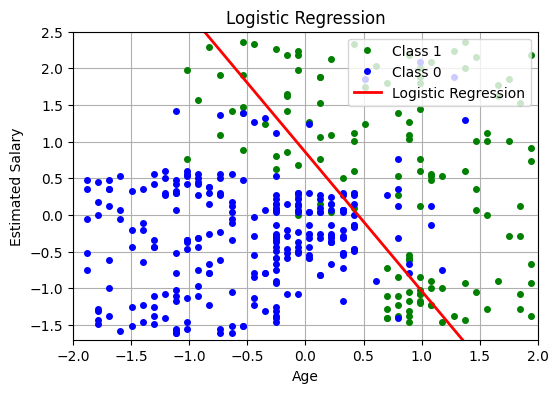

In [244]:
xp = np.linspace(-2, 2, 100).reshape(-1, 1)
yp = -w[1,0]/w[2,0]*xp - w[0,0]/w[2,0]

plt.figure(figsize=(6, 4))
plt.plot(X[C1, 1], X[C1, 2], 'go', markersize=4, label='Class 1')
plt.plot(X[C0, 1], X[C0, 2], 'bo', markersize=4, label='Class 0')
plt.plot(xp, yp, 'r', linewidth=2, label='Logistic Regression')
plt.xlim(-2, 2)
plt.ylim(-1.7, 2.5)
plt.title('Logistic Regression')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(loc=1)
plt.grid(True)
plt.show()

Scikit-learn Library 이용

In [245]:
X_train = X_train[:, 1:3]

X_train.shape

(320, 2)

In [246]:
clf = linear_model.LogisticRegression(solver='lbfgs', fit_intercept=False)

clf.fit(np.asarray(X_train), np.ravel(y_train))

LogisticRegression(fit_intercept=False)

파라미터(가중치)값

In [247]:
# w0 값 출력
print("w0 =",clf.intercept_[0])

w0 = 0.0


In [248]:
# w1 , w2 값 출력
print("w1 =",clf.coef_[0,0])
print("w2 =",clf.coef_[0,1])

w1 = 1.9551133018928726
w2 = 1.0718900533447981


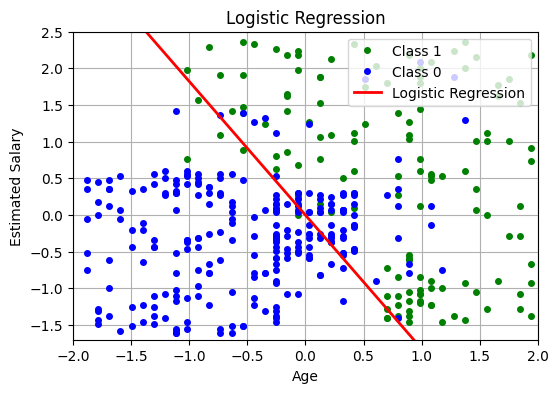

In [249]:
w0 = clf.intercept_[0]
w1 = clf.coef_[0,0]
w2 = clf.coef_[0,1]

xp = np.linspace(-2, 2, 100).reshape(-1, 1)
yp = - w1/w2*xp - w0/w2

plt.figure(figsize=(6, 4))
plt.plot(X[C1, 1], X[C1, 2], 'go', markersize=4, label='Class 1')
plt.plot(X[C0, 1], X[C0, 2], 'bo', markersize=4, label='Class 0')
plt.plot(xp, yp, 'r', linewidth=2, label='Logistic Regression')
plt.xlim(-2, 2)
plt.ylim(-1.7, 2.5)
plt.title('Logistic Regression')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(loc=1)
plt.grid(True)
plt.show()

X_test로 예측값(y_pred) 평가

In [250]:
from sklearn.metrics import accuracy_score

In [251]:
X_test = np.asarray(X_test)
X_test = X_test[:, 1:3]

In [252]:
y_pred = clf.predict(X_test)
result = accuracy_score(y_test, y_pred)

In [253]:
result

0.775